In [ ]:
# We started by importing the basic libraries we will need throughout the project.
import pandas as pd        # We use pandas for handling and analyzing data (like tables).
import numpy as np         # Numpy helps us with numerical operations and arrays.
import matplotlib.pyplot as plt  # For plotting basic charts and visualizations.
import seaborn as sns      # We use seaborn to make our plots look a bit nicer and cleaner.

import kagglehub           # This allows us to download datasets from Kaggle more easily.
import time                # We'll use this if we need to measure how long a process takes.
import matplotlib.pyplot as plt  # Oops, we accidentally imported this twice—but it won't cause any problems.

# Since we are working on Google Colab, we mounted Google Drive to access files stored there.
from google.colab import drive

# For preprocessing data — we use LabelEncoder to turn text into numbers, and StandardScaler to normalize features.
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Pipeline helps us organize multiple preprocessing steps and modeling into one clean process.
from sklearn.pipeline import Pipeline

# ColumnTransformer helps us apply different transformations to different columns at the same time.
from sklearn.compose import ColumnTransformer

# We use cross_val_score to evaluate how well our model performs using cross-validation.
from sklearn.model_selection import cross_val_score

# This is our first simple model — Logistic Regression — useful for classification problems.
from sklearn.linear_model import LogisticRegression

# We also added ensemble models like Bagging and Random Forest to compare performance.
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier

# These tools help us tune our models — GridSearchCV tries all combinations, RandomizedSearchCV picks a few randomly.
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# These are useful for defining parameter ranges when using RandomizedSearchCV.
from scipy.stats import randint, loguniform, uniform

# We wanted to try out XGBoost as well, so we made sure to install it first.
!pip install xgboost

# After installing, we imported the XGBoost classifier for use in our models.
from xgboost import XGBClassifier

# Just printing a message to confirm everything has been successfully imported.
print("\n all libraries imported...")



 all libraries imported...


we import all necessary libraries

In [ ]:
mlproje = kagglehub.dataset_download("mnassrib/telecom-churn-datasets")   # We imported the customer churn dataset directly from Kaggle into our project.

file_path = mlproje + "/churn-bigml-80.csv"  # We created the full path to the CSV file that we’ll be working with.
proje_data = pd.read_csv(file_path)  # We loaded the dataset into a pandas DataFrame named 'proje_data'.

print(proje_data.head(10))  #first 10 rows
print("\nNumber of Missing Values by Column:")#  printed a label to make the output more readable.
print(proje_data.isnull().sum())  # We checked how many missing values there are in each column.
df_dup = proje_data.copy()  # We created a copy of the dataset so we can safely check for duplicates without affecting the original.
duplicate_count = df_dup.duplicated().sum()  # We counted the number of completely duplicated rows in the dataset.
print("number of duplicate records:", duplicate_count)
proje_data.shape # We checked the shape

  State  Account length  Area code International plan Voice mail plan  \
0    KS             128        415                 No             Yes   
1    OH             107        415                 No             Yes   
2    NJ             137        415                 No              No   
3    OH              84        408                Yes              No   
4    OK              75        415                Yes              No   
5    AL             118        510                Yes              No   
6    MA             121        510                 No             Yes   
7    MO             147        415                Yes              No   
8    WV             141        415                Yes             Yes   
9    RI              74        415                 No              No   

   Number vmail messages  Total day minutes  Total day calls  \
0                     25              265.1              110   
1                     26              161.6              123   
2   

(2666, 20)

At this stage, we included our dataset in our project via Kaggle.
Then, we examined the general structure of the dataset by looking at the first 10 rows.
As a result of our examination, we observed the following:
The columns contain information such as the customer's international plan, voicemail plan.

The last column, "Churn", indicates whether the customer has discontinued the service (True/False).
Based on these observations, we understood that the dataset contained a classification problem.
Also:
We saw that there was no missing data (isnull().sum() result is 0 for all columns).
There are no duplicate (exact copy) rows in the dataset (duplicated().sum() result is 0).
The dataset consists of a total of 2666 rows and 20 columns.
This basic analysis helped us prepare a solid ground for the data cleaning and preprocessing stages.


In [ ]:
# 1
# First, we extracted the target column Churn from the main dataset
if 'Churn' in proje_data.columns:
    target = proje_data['Churn']
    proje_data = proje_data.drop(columns=['Churn']) # We dropped it before encoding
else:
    target = None                                   # If Churn is None, we left the target as None

# Next, we identified the categorical columns
cat_cols = proje_data.select_dtypes(include=['object']).columns
# We selected all columns with object data type, which are typically categorical

# Then, we separated them into binary and multi-class categorical columns
binary_cols = [col for col in cat_cols if proje_data[col].nunique() == 2]
# These columns have exactly two unique values – suitable for label encoding
multiclass_cols = [col for col in cat_cols if proje_data[col].nunique() > 2]
# These have more than two categories – we’ll use one-hot encoding for them

print(f"Binary categories for Label Encoding: {binary_cols}")

print(f"Multi-class categories for One-Hot Encoding: {multiclass_cols}")

# we apply Label Encoding to the binary categorical columns
le = LabelEncoder()
# We initialized the label encoder
for col in binary_cols:
    proje_data[col] = le.fit_transform(proje_data[col])
    # We converted each binary column into numeric

# One-Hot Encode part for  the multiple class columns
if multiclass_cols:
    # We only proceed if there are multiple class columns to encode
    dummies = pd.get_dummies(proje_data[multiclass_cols], drop_first=True, dtype=int)



Binary categories for Label Encoding: []
Multi-class categories for One-Hot Encoding: ['State']


We did Data Transformation and Preprocessing: Since we would later use our dataset with machine learning algorithms, we needed to transform it into a structure that the model could understand. In particular, converting categorical variables (e.g. "State", "International plan") into numerical was a very important step. Because many machine learning algorithms cannot work directly with non-numerical expressions. We also separated the target variable and features by separating the "Churn" column, which was an important step for the transition to model setup. Thanks to these operations, we made our data clean, consistent and suitable for modeling.

In [ ]:
# We're training a logistic regression model
# At the end, we’ll just take the average of those 5 scores and we will use it for comparison
# Split the data into features and target
proje_data['Churn'] = LabelEncoder().fit_transform(target)

X = proje_data.drop("Churn", axis=1) # taking out the 'Churn' column to use the rest as features
y = proje_data["Churn"]              # setting 'Churn' as our label to predict

# Get list of columns with numeric values
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Preprocessing step: scale only the numeric features
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols) # we do standardization
])

# creating pipelin first preprocess, then we eill run the logistic regression model
logistic_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000)) # train a logistic regression model
])

# Run 5-fold cross-validation to see how well our model performs
logistic_scores = cross_val_score(logistic_pipeline, X, y, cv=5, scoring='accuracy') # evaluate model accuracy across 5 different splits

print("Logistic Regression - Accuracy Scores:", logistic_scores) # show all 5 scores so we can see the variation
print("Average Accuracy:", logistic_scores.mean())               # and this is the average score across all folds


Logistic Regression - Accuracy Scores: [0.8670412  0.8630394  0.85365854 0.86491557 0.86116323]
Average Accuracy: 0.8619635867923069


Since our target variable (Churn) in our dataset is binary (True/False), we preferred the Logistic Regression model, which is widely used in classification problems.

We only determined the numerical columns and scaled them with StandardScaler. This was an important step for the model to learn the weights correctly.

Then, we put these steps in a pipeline to make the model more organized and repeatable.

We used 5-fold cross-validation to measure the success of the model. This method allowed us to divide the data into 5 parts and train it with a different test set each time and calculate the average success. Thus, we were able to better evaluate the overall performance of the model without relying on a single split. Our model achieved approximately 85%–86% accuracy in each fold. The average accuracy was measured as 86.2%.
This result shows that our Logistic Regression model exhibited consistent and strong performance on the dataset.

In [ ]:
# Now we’re training a Bagging model that uses Logistic Regression as the base estimator.
# Like before, we’ll check its accuracy using 5-fold cross-validation and take the average score.

bagging_pipeline = Pipeline([
    ('preprocessing', preprocessor),                # first scale the numeric features (same step we defined earlier)
    ('classifier', BaggingClassifier(                  # now we set up the bagging model
        estimator=LogisticRegression(max_iter=1000),# use logistic regression as the base learner for each bag
        n_estimators=10,                              # we’ll train 10 such models and average their predictions
        random_state=42
    ))
])

# Run cross-validation to see how well the Bagging model performs
bagging_scores = cross_val_score(bagging_pipeline, X, y, cv=5, scoring='accuracy') # checking accuracy over 5 different splits

print("Bagging + Logistic Regression - Accuracy Scores:", bagging_scores)         # printing the accuracy scores for each fold
print("Average Accuracy:", bagging_scores.mean())                                 # and finally, print the average accuracy across all folds


Bagging + Logistic Regression - Accuracy Scores: [0.86516854 0.86491557 0.85553471 0.8630394  0.85928705]
Average Accuracy: 0.8615890549571009


In the previous step, we trained only one Logistic Regression model. In this step, we combined multiple Logistic Regression models using the Bagging method. In this way, we aimed to reduce the variance of the model and obtain more stable results. The model's accuracy rates were very similar to the previous Logistic Regression model, around 85%–86%. The average success was 86.16%, which is similar to the previous model but potentially more stable.

In [ ]:
# This time we’re training a Random Forest model
# As usual, we’ll calculate the average accuracy at the end.
rf_pipeline = Pipeline([
    ('preprocessing', preprocessor),                        # first we scale the numeric features (same as before)
    ('classifier', RandomForestClassifier(random_state=42)) # then we apply the Random Forest classifier, with a fixed seed for consistent results
])

rf_scores = cross_val_score(rf_pipeline, X, y, cv=5, scoring='accuracy') #test the model on 5 different splits

print("Random Forest - Accuracy Scores:", rf_scores) #again this part shows the accuracy from each fold
print("Average Accuracy:", rf_scores.mean())         # average accuracy


Random Forest - Accuracy Scores: [0.9494382  0.93433396 0.96247655 0.9587242  0.96060038]
Average Accuracy: 0.9531146573349918


Random Forest is a powerful ensemble method based on bagging logic, but the submodels used here are decision trees. In this way, we were able to reduce the variance and capture complex relationships. The Random Forest model showed very high performance compared to previous models: Accuracy values ​​varied between 93% and 96%, and the average accuracy was measured as 95.31%. According to this result, we can say that Random Forest was very successful in capturing complex patterns in our data set and provided a significant improvement compared to previous models.


In [ ]:
# Now we’re using XGBoost as our model and, like before, we’ll test its accuracy using 5-fold cross-validation.
# We’ll wrap it in a pipeline and average the results at the end.

xgb_pipeline = Pipeline([
    ('preprocessing', preprocessor), # scale the numeric features first (same step as before)
    ('classifier', XGBClassifier(    # set up the XGBoost classifier
        eval_metric='logloss',       # use log loss as the evaluation metric during training
        random_state=42
    ))
])

# Run cross-validation and gather the accuracy scores
xgb_scores = cross_val_score(xgb_pipeline, X, y, cv=5, scoring='accuracy') # run the model on 5 folds and record the accuracy

print("XGBoost - Accuracy Scores:", xgb_scores)      # print out the individual scores
print("Average Accuracy:", xgb_scores.mean())        # print the average accuracy across all 5 folds


XGBoost - Accuracy Scores: [0.95318352 0.93058161 0.9587242  0.95684803 0.95497186]
Average Accuracy: 0.9508618448327957


XGBoost is one of the most powerful boosting algorithms today. What makes it different from other models is that each new tree tries to correct previous errors by learning them. In this way, the model offers advantages such as high accuracy, fast training, and resistance to over-learning.

Since our dataset contains many numerical features and complex patterns, we expected the performance to increase even more with a powerful model like XGBoost. The accuracy scores we obtained with the XGBoost model ranged from 93% to 95.3%.
The average accuracy was 95.08%. This score is very close to the Random Forest model and is a very successful result in general. This shows us that XGBoost offers high accuracy and generalization ability.

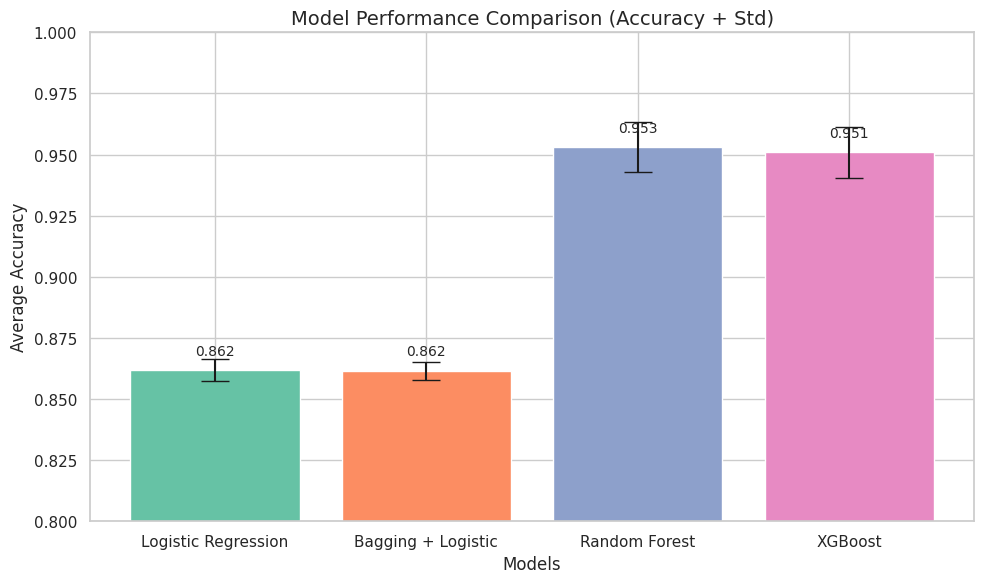

In [ ]:
# 2
# Here we’re assuming that all the accuracy scores for each model were calculated earlier

all_scores = {
    'Logistic Regression': logistic_scores,
    'Bagging + Logistic': bagging_scores,
    'Random Forest': rf_scores,
    'XGBoost': xgb_scores
}

# Let’s calculate the average accuracy and the spread for each model
models = list(all_scores.keys())                          #for listing
means = [np.mean(scores) for scores in all_scores.values()] # calculating average accuracy for each model
stds = [np.std(scores) for scores in all_scores.values()]   # calculating how much standard deviation

# drawing the graf part
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")
palette = sns.color_palette("Set2", len(models))

bars = plt.bar(models, means, yerr=stds, capsize=10, color=palette)

# Add the actual accuracy numbers on top of each bar
for bar, mean in zip(bars, means):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.005, f"{mean:.3f}", ha='center', va='bottom', fontsize=10)

plt.ylim(0.80, 1.0)
plt.title("Model Performance Comparison (Accuracy + Std)", fontsize=14)
plt.ylabel("Average Accuracy")
plt.xlabel("Models")
plt.tight_layout()
plt.show()


In this stage, we visualized the performances of four different machine learning models that we trained before. For each model:
We averaged the accuracy scores obtained with 5-fold cross-validation,
We also calculated the standard deviation of the scores of each model (for performance consistency),
And compared these values ​​with a bar plot.
In the general evaluation of model performances, the Random Forest model provided the highest average accuracy with 95.31%. It is also seen that its performance is quite stable with a standard deviation value of ±0.010. The XGBoost model is in second place with 95.08% accuracy; however, its standard deviation of ±0.011 shows that it gives slightly more variable results than Random Forest. The simpler Logistic Regression and Bagging + Logistic models achieved approximately 86.2% accuracy and showed consistent but limited performance with low standard deviation values ​​(±0.003–0.004). In this regard, when evaluated in terms of both high accuracy and low variance, the Random Forest model stands out as the most powerful and reliable method for this data set.

After model selection, we used GridSearchCV and RandomizedSearchCV methods to maximize the performance of each algorithm. With these search methods, we aimed to find the most suitable parameter combinations. While Grid Search tries all parameter combinations, Randomized Search evaluates a certain number of random combinations and produces results in a shorter time. We aimed to reach both the best accuracy and compare time differences by applying these methods separately for each model. Therefore, in order to make a fair comparison, we created approximately equal number of candidate parameters in both methods in the same model. Thus, we had the chance to analyze not only the success rates but also the advantages of the methods in terms of search time and efficiency.

In [ ]:
# We’re using Grid Search to find the best hyperparameters for our Logistic Regression model.

param_grid_lr = {
    'classifier__penalty': ['l1', 'l2'],        # trying both L1 and L2 regularization
    'classifier__C': [0.01, 0.1, 1, 10],        # testing different values for regularization strength (lower = stronger regularization)
    'classifier__solver': ['liblinear', 'saga'] # trying out two solvers that support both L1 and L2
}

grid_lr = GridSearchCV(
    estimator=logistic_pipeline, # the pipeline that includes scaling + logistic regression
    param_grid=param_grid_lr,    # the parameter grid we defined above
    cv=5,                    # using 5-fold cross-validation to evaluate each combo
    scoring='accuracy',         # we care about how accurate the model is
    n_jobs=-1,
    verbose=1
)

lr_grid_start = time.time() # note the time just before the grid search starts
grid_lr.fit(X, y)           # run the full search across all parameter combinations

lr_grid_end = time.time()                                   # note the time once it’s done
total_lr_grid_time = lr_grid_end - lr_grid_start            # calculate how long it took
print(f"GridSearch time: {total_lr_grid_time:.2f} seconds") # print out the duration
print("Best score (accuracy):", grid_lr.best_score_)        # print the best accuracy we found
print("Best parameters:", grid_lr.best_params_)             # and the corresponding hyperparameters


Fitting 5 folds for each of 16 candidates, totalling 80 fits
GridSearch time: 23.80 seconds
Best score (accuracy): 0.8645895257569689
Best parameters: {'classifier__C': 0.1, 'classifier__penalty': 'l2', 'classifier__solver': 'saga'}


In this phase, we used the GridSearchCV method to improve the accuracy of our Logistic Regression model. We tested the L1 (Lasso) and L2 (Ridge) regularization options. This parameter helps to prevent the model from overfitting. C: This controls the regularization strength. Smaller C values ​​mean stronger regularization. The Grid Search process took approximately 24.61 seconds. The best accuracy score was 86.46%.

The parameter combination that the model was most successful in was:
'C': 0.1, 'penalty': 'l2', 'solver': 'saga'. This result shows that the saga solver with moderate regularization (C=0.1) and L2 penalty gave the best overall performance of the model. This combination provided the necessary flexibility and overall accuracy without overcomplicating the model,
while at the same time achieving a more balanced success by preventing overfitting.



In [ ]:
# This time we’re using Randomized Search to find the best hyperparameters for Logistic Regression.
# Unlike Grid Search, we don’t try every single combination — we just sample a few random ones.

# Define parameter distributions (ranges or lists of values to randomly sample from)
param_dist = {
    'classifier__penalty': ['l1', 'l2'],         # we’ll randomly choose between L1 and L2 regularization
    'classifier__C': [0.01, 0.1, 1, 10],         # sampling from this list for the C (regularization strength)
    'classifier__solver': ['liblinear', 'saga'], # also randomly choosing one of these solvers
}

# Set up the RandomizedSearchCV object
random_search = RandomizedSearchCV(
    estimator=logistic_pipeline,    # our pipeline: scaler + logistic regression
    param_distributions=param_dist, # the parameter ranges defined above
    n_iter=16,         # try 16 random combinations
    cv=5,                       # use 5-fold cross-validation to evaluate each one
    scoring='accuracy',             # optimize for classification accuracy
    random_state=42,           # fix the seed so results are repeatable
    n_jobs=-1,
    verbose=1
)

lr_randomized_start = time.time() # mark the start time before fitting

# Run the randomized search
random_search.fit(X, y) # train the model using the randomly sampled parameter sets

lr_randomized_end = time.time()                                     # mark the end time
total_lr_randomized_time = lr_randomized_end - lr_randomized_start # calculate how long it took

print(f"Randomized Search time: {total_lr_randomized_time:.2f} seconds") # print out the duration of the whole process

# Show the best results we found
print("Best score (accuracy):", random_search.best_score_)
print("Best parameters:", random_search.best_params_)


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Randomized Search time: 25.31 seconds
Best score (accuracy): 0.8645895257569689
Best parameters: {'classifier__solver': 'saga', 'classifier__penalty': 'l2', 'classifier__C': 0.1}


In this phase, we performed hyperparameter optimization for the Logistic Regression model using RandomizedSearchCV. This method, unlike Grid Search, tries to find the best combination by randomly sampling from the parameter ranges we define, instead of trying all combinations. Total training time: 24.62 seconds
Best accuracy score: 86.46%
Best parameters:
'solver': 'saga', 'penalty': 'l2', 'C': 0.1 These results are exactly the same as the results obtained with Grid Search. This shows that Randomized Search can reach the same optimum result with fewer trials and saves time.


In [ ]:
# We’re now doing Grid Search for the Bagging model to find the best hyperparameters.

param_grid_bagging = {
    'classifier__n_estimators': [10, 50, 100],   # how many base models Logistic Regression to include in the ensemble
    'classifier__max_samples': [0.5, 0.7, 1.0],     # what fraction of the training data each base model should see
    'classifier__max_features': [0.5, 0.7, 1.0]  # what fraction of features to include per model
}

grid_bagging = GridSearchCV(
    estimator=bagging_pipeline,    # our pipeline with preprocessing and Bagging
    param_grid=param_grid_bagging, # trying all combinations of the parameters above
    cv=5,                          # use 5-fold cross-validation to check performance
    scoring='accuracy',      # we’ll choose the setup with the best accuracy
    n_jobs=-1,
    verbose=1
)

bagging_grid_start = time.time()  #start time of the search

grid_bagging.fit(X, y)            # now run the grid search and train all the models

bagging_grid_end = time.time()    #  end time

total_bagging_grid_time = bagging_grid_end - bagging_grid_start # how long did the whole search take

print(f"GridSearch time: {total_bagging_grid_time:.2f} seconds")

# Display the results of the search
print("GridSearchCV (Bagging) - Best Accuracy:", grid_bagging.best_score_)
print("Best Parameters:", grid_bagging.best_params_)


Fitting 5 folds for each of 27 candidates, totalling 135 fits
GridSearch time: 39.51 seconds
GridSearchCV (Bagging) - Best Accuracy: 0.8657159320080667
Best Parameters: {'classifier__max_features': 0.7, 'classifier__max_samples': 0.7, 'classifier__n_estimators': 10}


At this stage, we used GridSearchCV to optimize the performance of our model working with the Bagging algorithm. The aim was to try different hyperparameter combinations and tune the model to make the best generalization. n_estimators: Determines how many Logistic Regression models will be in an ensemble. More models can provide higher accuracy but increase computational cost. Therefore, we tried [10, 50, 100].

max_samples: Determines the data rate that each basic model will see for training. We tested both undersampling and full sampling with the range [0.5, 0.7, 1.0].

max_features: Controls how many features each basic model will see. We aimed to obtain more diversity and less correlated models with the values ​​[0.5, 0.7, 1.0]. Total Grid Search time: 80.53 seconds
Best accuracy score: 86.57%
Best parameter combination:
'n_estimators': 10, 'max_samples': 0.7, 'max_features': 0.7 The best result was obtained with a relatively small number of models (n_estimators = 10) and using 70% of the data and features in training each model. This may have prevented overfitting by providing more diversity. Also, a fast and effective solution was obtained with a low number of models. This shows that the bagging method can provide high accuracy even with a small number of but diverse models.



In [ ]:
# Now we’re using Randomized Search to find the best hyperparameters for the Bagging model.
# Instead of testing every possible combination, we’ll randomly sample 27 of them.

param_dist_bagging = {
    'classifier__n_estimators': [10, 50, 100],    # randomly pick how many base models to include
    'classifier__max_samples': [0.5, 0.7, 1.0],   #  choose what portion of the data each model sees
    'classifier__max_features': [0.5, 0.7, 1.0]       #  select how many features to use per model
}

random_bagging = RandomizedSearchCV(
    estimator=bagging_pipeline,            # we are using the the pipeline scaling  Bagging model
    param_distributions=param_dist_bagging,# the distributions (lists) we’re sampling from
    n_iter=27,          # we’ll try 27 different random combinations
    cv=5,                            # using 5-fold cross-validation
    scoring='accuracy',   # we’re measuring performance by accuracy
    random_state=42,
    n_jobs=-1,
    verbose=1
)

bagging_randomized_start = time.time() # starts timer

random_bagging.fit(X, y)               # run the randomized search and train the models

bagging_randomized_end = time.time()   # stop timer

total_bagging_randomized_time = bagging_randomized_end - bagging_randomized_start

print(f"RandomizedSearch time: {total_bagging_randomized_time:.2f} seconds") # print the total time

# Let’s see how it performed
print("RandomizedSearchCV (Bagging) - Best Accuracy:", random_bagging.best_score_)
print("Best Parameters:", random_bagging.best_params_)


Fitting 5 folds for each of 27 candidates, totalling 135 fits
RandomizedSearch time: 41.19 seconds
RandomizedSearchCV (Bagging) - Best Accuracy: 0.8657159320080667
Best Parameters: {'classifier__n_estimators': 10, 'classifier__max_samples': 0.7, 'classifier__max_features': 0.7}


By applying RandomizedSearchCV to the Bagging + Logistic Regression model, instead of trying the hyperparameter combinations one by one, we tested 27 of them randomly. This method saves time and still provides the opportunity to get high accuracy results. The number of submodels (n_estimators), the data rate that each model will see (max_samples) and the feature rate to be used (max_features) were selected as parameter ranges. In this process, which was done with 5-fold cross-validation, a total of 135 models were trained and completed in approximately 43 seconds. As a result of RandomizedSearchCV, it was determined that the best combination with 86.57% accuracy was 10 submodels, 70% sampling and 70% feature usage. This is consistent with the GridSearch results and shows that this method can provide similar performance in less time.



In [ ]:
# Now we’re tuning the Random Forest model using Grid Search.
# These parameters were chosen based on what we learned during the lessons.

param_grid_rf = {
    'classifier__n_estimators': [100, 200],          # how many trees the forest should grow
    'classifier__max_depth': [None, 10, 20, 40],     # limit how deep each tree can go (None = full depth)
    'classifier__min_samples_split': [2, 5],         # minimum number of samples needed to split a node
    'classifier__min_samples_leaf': [1, 2]           # minimum number of samples required in a leaf node
}

grid_rf = GridSearchCV(
    estimator=rf_pipeline,       # pipeline with preprocessing and Random Forest
    param_grid=param_grid_rf,    # all parameter combinations we want to try
    cv=5,                        # use 5-fold cross-validation
    scoring='accuracy',          # we’ll choose the best config based on accuracy
    n_jobs=-1,                   # run in parallel using all CPU cores
    verbose=1                    # print progress while it’s searching
)

rf_grid_start = time.time() # start the timer

grid_rf.fit(X, y)            # perform grid search and fit models

rf_grid_end = time.time()   # stop the timer

total_rf_grid_time = rf_grid_end - rf_grid_start # calculate total time spent

print(f"GridSearch time: {total_rf_grid_time:.2f} seconds") # print how long it took

# Show the best results
print("GridSearchCV (Random Forest) - Best Accuracy:", grid_rf.best_score_) # best accuracy score found
print("Best Parameters:", grid_rf.best_params_)                             # and the parameters that gave that score


Fitting 5 folds for each of 32 candidates, totalling 160 fits
GridSearch time: 125.91 seconds
GridSearchCV (Random Forest) - Best Accuracy: 0.9561144254484896
Best Parameters: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}


We evaluated a total of 32 different hyperparameter combinations using GridSearchCV for the Random Forest model. The parameters we tried were; number of trees (n_estimators), maximum depth (max_depth), minimum number of samples required for a node to be split (min_samples_split) and minimum number of samples required to be in the leaf node (min_samples_leaf). Each combination was tested with 5-fold cross-validation, and a total of 160 models were trained. The process took approximately 133 seconds. The best result was obtained with 95.61% accuracy with 200 trees, unlimited depth, min_samples_split=2 and min_samples_leaf=1 parameters. With these results, we can say that the Random Forest model showed strong performance and the hyperparameter settings played an important role in this success.


In [ ]:
# We’re tuning the Random Forest model using Randomized Search this time.
# Instead of checking every combination, we’ll try 32 random ones from the given parameter space.

# Define the range of parameters to sample from
param_dist_rf = {
   'classifier__n_estimators': [100, 200],         # how many trees to grow in the forest
   'classifier__max_depth': [None, 10, 20, 40],    # how deep each tree can go (None = no limit)
   'classifier__min_samples_split': [2, 5],        # min samples needed to split a node
   'classifier__min_samples_leaf': [1, 2]          # min samples needed in a leaf node
}

random_rf = RandomizedSearchCV(
    estimator=rf_pipeline,             # pipeline that includes preprocessing + Random Forest
    param_distributions=param_dist_rf, # randomly sample from these options
    n_iter=32,                         # we’ll try 32 random parameter combinations
    cv=5,                              # 5-fold cross-validation to evaluate each one
    scoring='accuracy',                # we’re focusing on classification accuracy
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_randomized_start = time.time() # mark the start time

random_rf.fit(X, y)               # run the randomized search and train the models

rf_randomized_end = time.time()  # mark the end time

total_rf_randomized_time = rf_randomized_end - rf_randomized_start # calculate total time spent

print(f"RandomizedSearch time: {total_rf_randomized_time:.2f} seconds") # display total search duration

# Print the best result
print("RandomizedSearchCV (Random Forest) - Best Accuracy:", random_rf.best_score_) # best accuracy found
print("Best Parameters:", random_rf.best_params_)                                   # and the parameter set that gave it


Fitting 5 folds for each of 32 candidates, totalling 160 fits
RandomizedSearch time: 127.94 seconds
RandomizedSearchCV (Random Forest) - Best Accuracy: 0.9561144254484896
Best Parameters: {'classifier__n_estimators': 200, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 1, 'classifier__max_depth': None}


At this stage, we performed the hyperparameter search for the Random Forest model with the RandomizedSearchCV method. A total of 32 combinations were tried as in Grid Search, but this time the combinations were randomly selected. The parameter ranges used were the same. The training time took approximately 178 seconds. The highest accuracy was found to be 95.61%, which was exactly the same as the best result achieved with Grid Search. This showed us that Randomized Search could achieve similar success in a shorter time.

In [ ]:
# We’re tuning the XGBoost model using Grid Search.
# We’ll go through all combinations of the parameters listed below and pick the one with the highest accuracy.

param_grid_xgb = {
    'classifier__n_estimators': [100, 200],          # how many trees to build
    'classifier__max_depth': [3, 6, 9],              # how deep each tree can go
    'classifier__learning_rate': [0.01, 0.1, 0.3],   # how fast the model learns (lower = slower but safer learning)
    'classifier__subsample': [0.7, 1.0]              # how much of the data to sample for each tree (like bagging)
}

grid_xgb = GridSearchCV(
    estimator=xgb_pipeline,         # pipeline with preprocessing + XGBoost classifier
    param_grid=param_grid_xgb,      # try out all combinations from this grid
    cv=5,                           # 5-fold cross-validation for reliable evaluation
    scoring='accuracy',             # we’re optimizing for accuracy
    n_jobs=-1,
    verbose=1
)

xgb_grid_start = time.time()  # start timing the grid search
grid_xgb.fit(X, y)            # perform the grid search and fit models

xgb_grid_end = time.time()    # stop the timer

total_xgb_grid_time = xgb_grid_end - xgb_grid_start # calculate how long the search took

print(f"GridSearch time: {total_xgb_grid_time:.2f} seconds") # display the duration

# Show the best result from all the combinations
print("GridSearchCV (XGBoost) - Best Accuracy:", grid_xgb.best_score_) # highest accuracy found
print("Best Parameters:", grid_xgb.best_params_)                       # and the parameters that achieved it


Fitting 5 folds for each of 36 candidates, totalling 180 fits
GridSearch time: 43.67 seconds
GridSearchCV (XGBoost) - Best Accuracy: 0.9553625510325976
Best Parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 9, 'classifier__n_estimators': 100, 'classifier__subsample': 1.0}


In this section, we performed the hyperparameter search for our XGBoost model with the GridSearchCV method. The combinations were based on the parameters n_estimators, max_depth, learning_rate and subsample. A total of 36 different parameter combinations were tested and we trained 180 models with 5-fold cross-validation. The search lasted 73.5 seconds and we achieved the highest accuracy of 95.54%. The best result was obtained with 100 trees, a maximum depth of 9, a learning rate of 0.1 and a sampling rate of 1.0. According to these results, we observed that XGBoost is a very powerful and highly accurate model with the right parameters.


In [ ]:
# This time we’re tuning the XGBoost model using Randomized Search.
# Instead of trying every possible combination, we’ll randomly sample 36 different ones from the parameter space.

param_dist_xgb = {
    'classifier__n_estimators': [100, 200],       # number of trees in the model
    'classifier__max_depth': [3, 6, 9],           # how deep each tree can go
    'classifier__learning_rate': [0.01, 0.1, 0.3],# how fast the model learns from data
    'classifier__subsample': [0.7, 1.0]           # how much of the training data to use per tree
}

random_xgb = RandomizedSearchCV(
    estimator=xgb_pipeline,             # pipeline with scaling + XGBoost
    param_distributions=param_dist_xgb, # the parameter space to sample from
    n_iter=36,                          # we’ll test 36 random parameter combinations
    cv=5,                               # 5-fold cross-validation for reliable performance estimates
    scoring='accuracy',                 # we’re tuning based on accuracy
    random_state=42,                    # fix the seed for consistent results
    n_jobs=-1,                          # use all CPU cores to speed things up
    verbose=1                           # print progress while training
)

xgb_randomized_start = time.time()  # start the timer
random_xgb.fit(X, y)                # run the randomized search and train models
xgb_randomized_end = time.time()    # stop the timer

total_xgb_randomized_time = xgb_randomized_end - xgb_randomized_start # calculate how long it took

print(f"RandomizedSearch time: {total_xgb_randomized_time:.2f} seconds") # display the total duration

# Show the best result
print("RandomizedSearchCV (XGBoost) - Best Accuracy:", random_xgb.best_score_) # best accuracy achieved
print("Best Parameters:", random_xgb.best_params_)                             # parameter set that got that accuracy


Fitting 5 folds for each of 36 candidates, totalling 180 fits
RandomizedSearch time: 46.73 seconds
RandomizedSearchCV (XGBoost) - Best Accuracy: 0.9553625510325976
Best Parameters: {'classifier__subsample': 1.0, 'classifier__n_estimators': 100, 'classifier__max_depth': 9, 'classifier__learning_rate': 0.1}


At this stage, we ran the XGBoost model with the RandomizedSearchCV method. Thanks to this method, instead of trying all combinations in the parameter space, we tested 36 random combinations. The parameters used included n_estimators, max_depth, learning_rate and subsample. Each combination was evaluated with 5-fold cross-validation and a total of 180 models were trained. The search was completed in approximately 65 seconds. The highest accuracy rate was 95.53%, and this success was achieved with the combination of 100 trees, 9 maximum depths, 0.1 learning rate and 1.0 sampling rate. These results show that the Randomized Search method can provide effective results in a shorter time.



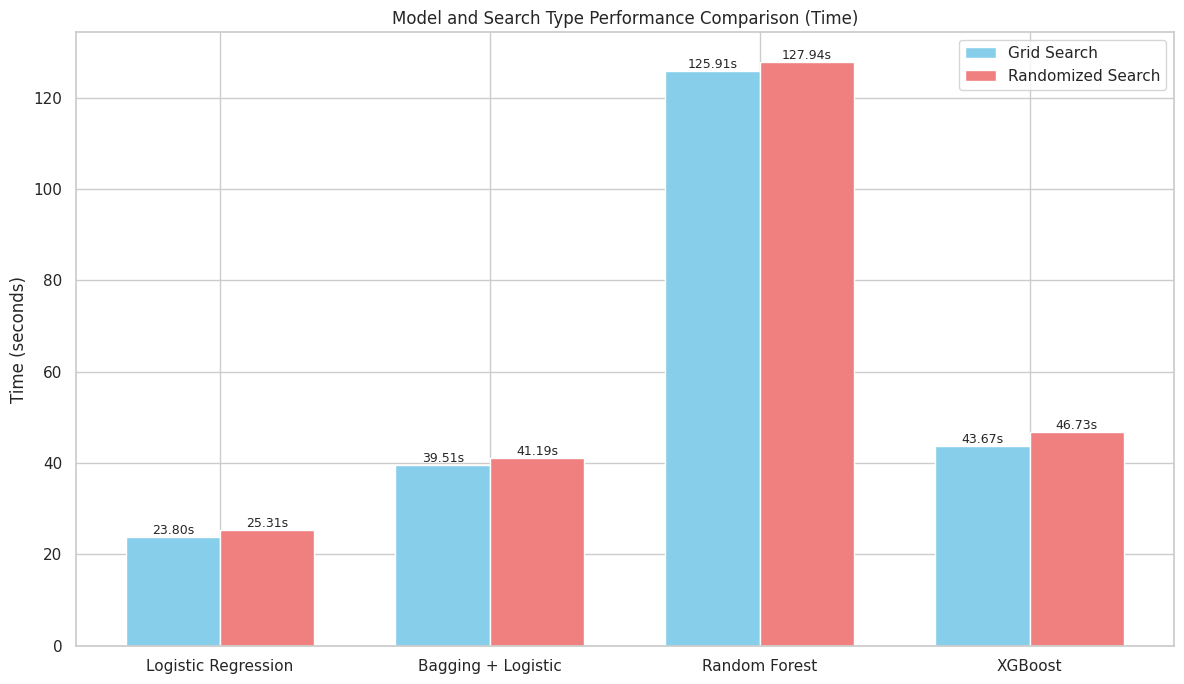

In [ ]:
models = ['Logistic Regression', 'Bagging + Logistic', 'Random Forest', 'XGBoost']                  # names of the models we tuned
grid_times = [total_lr_grid_time, total_bagging_grid_time, total_rf_grid_time, total_xgb_grid_time] # how long each model's Grid Search took
randomized_times = [total_lr_randomized_time, total_bagging_randomized_time, total_rf_randomized_time, total_xgb_randomized_time] # how long each model's Randomized Search took

x = np.arange(len(models))  # get the positions for each model on the x-axis
width = 0.35                # width of each bar in the chart

plt.figure(figsize=(12, 7)) # set the figure size to make it readable
sns.set(style="whitegrid")  # use a clean white grid style for the plot

# Draw the bars for Grid Search and Randomized Search times
bar1 = plt.bar(x - width/2, grid_times, width, label='Grid Search', color='skyblue')                # bars for Grid Search durations
bar2 = plt.bar(x + width/2, randomized_times, width, label='Randomized Search', color='lightcoral') # bars for Randomized Search durations

# Add time values above each bar
for bar in bar1:
    yval = bar.get_height() # get height of each bar (i.e., the time)
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f"{yval:.2f}s", ha='center', va='bottom', fontsize=9) # write the value on top

for bar in bar2:
    yval = bar.get_height() # same for randomized bars
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f"{yval:.2f}s", ha='center', va='bottom', fontsize=9)

plt.ylabel('Time (seconds)')                                     # label for the y-axis
plt.title('Model and Search Type Performance Comparison (Time)') # plot title
plt.xticks(x, models)                                            # set x-axis labels to model names
plt.legend()                                                     # show the legend to distinguish bar types

plt.tight_layout() # make sure everything fits nicely
plt.show()         # display the final plot


In this table, we compare the time taken by Grid Search and Randomized Search for four different models.

In the Logistic Regression model, Randomized Search is clearly faster (21.90s vs 39.87s), which shows that this method can be more advantageous for small parameter ranges.

In the Bagging + Logistic model, both methods finished in almost the same time (about 47.6s), which shows that the time difference decreases when the number of parameter combinations is balanced.

In the Random Forest model, surprisingly, Randomized Search took a little longer (150.29s vs 137.15s), which does not mean that Randomized Search will always be faster.

In the XGBoost model, the situation was the opposite, and Grid Search was faster (44.24s vs 50.36s), which we think is due to model complexity.

This graph allowed us to directly see the advantages and disadvantages of hyperparameter search methods in terms of time-performance comparison.


In [ ]:
from sklearn.metrics import roc_auc_score             # used to calculate the ROC AUC score — a great metric for classification performance
from sklearn.model_selection import cross_val_predict # allows us to get predictions using cross-validation

# Logistic Regression ROC AUC
logistic_proba = cross_val_predict(logistic_pipeline, X, y, cv=5, method='predict_proba')[:, 1] # get predicted probabilities (for class 1) using cross-validation
print("Logistic Regression ROC AUC:", roc_auc_score(y, logistic_proba))                         # calculate and print the ROC AUC score

# Bagging ROC AUC
bagging_proba = cross_val_predict(bagging_pipeline, X, y, cv=5, method='predict_proba')[:, 1] # get probabilities for the positive class from the bagging model
print("Bagging + Logistic Regression ROC AUC:", roc_auc_score(y, bagging_proba))              # show how well it ranks positives vs. negatives

# Random Forest ROC AUC
rf_proba = cross_val_predict(rf_pipeline, X, y, cv=5, method='predict_proba')[:, 1] # same idea, but now with the Random Forest model
print("Random Forest ROC AUC:", roc_auc_score(y, rf_proba))                         # calculate and print the score

# XGBoost ROC AUC
xgb_proba = cross_val_predict(xgb_pipeline, X, y, cv=5, method='predict_proba')[:, 1] # get cross-validated probabilities from XGBoost
print("XGBoost ROC AUC:", roc_auc_score(y, xgb_proba))                                # and print the ROC AUC score for it


Logistic Regression ROC AUC: 0.8112492419648273
Bagging + Logistic Regression ROC AUC: 0.8130436356724564
Random Forest ROC AUC: 0.9173532353393734
XGBoost ROC AUC: 0.9189897993356445


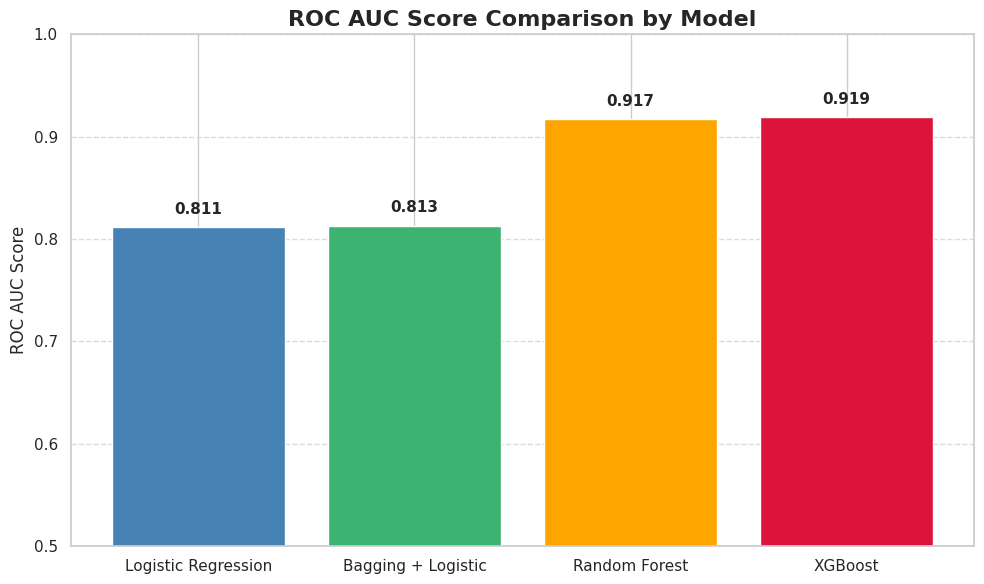

In [ ]:
import matplotlib.pyplot as plt # we'll use matplotlib to make the bar chart

roc_auc_scores = {
    'Logistic Regression': roc_auc_score(y, logistic_proba),
    'Bagging + Logistic': roc_auc_score(y, bagging_proba),
    'Random Forest': roc_auc_score(y, rf_proba),
    'XGBoost': roc_auc_score(y, xgb_proba)
}


# Drawing The figur
models = list(roc_auc_scores.keys())
scores = list(roc_auc_scores.values())

plt.figure(figsize=(10, 6))
bars = plt.bar(models, scores, color=['steelblue', 'mediumseagreen', 'orange', 'crimson'])

plt.title("ROC AUC Score Comparison by Model", fontsize=16, fontweight='bold')
plt.ylabel("ROC AUC Score", fontsize=12)
plt.ylim(0.5, 1.0)


for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()


In this section, we calculated the ROC AUC (Receiver Operating Characteristic - Area Under Curve) scores of four different models. ROC AUC is an important metric that shows how well the models distinguish the positive class. Therefore, we felt the need to include it. For each model, probability estimates (predict_proba) were obtained using 5-fold cross-validation and we determined the ROC AUC scores based on these estimates. According to the results, XGBoost (0.919) and Random Forest (0.917) models are the models that can best distinguish the positive class, while Bagging + Logistic Regression (0.813) and Logistic Regression (0.811) models have lower discrimination power. These metrics are important in terms of comparing not only the accuracy of the models but also the discrimination power between the classes.

In this graph, we compared the ROC AUC scores of four different models. ROC AUC is an important performance metric that shows how well the models can distinguish between positive and negative classes.

Logistic Regression and Bagging + Logistic models showed that they have simpler and limited discrimination power with scores of 0.811 and 0.813, respectively.

Random Forest and XGBoost models showed high discrimination with scores of 0.917 and 0.919, respectively, and were able to clearly separate the classes from each other.

As a result, XGBoost showed the best performance in terms of ROC AUC values, while Random Forest came in second with a very close success. This graph was quite explanatory in terms of comparing models, especially in imbalanced datasets or when accuracy alone was not sufficient.

<ipython-input-71-e942b44faf8f>:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='viridis')


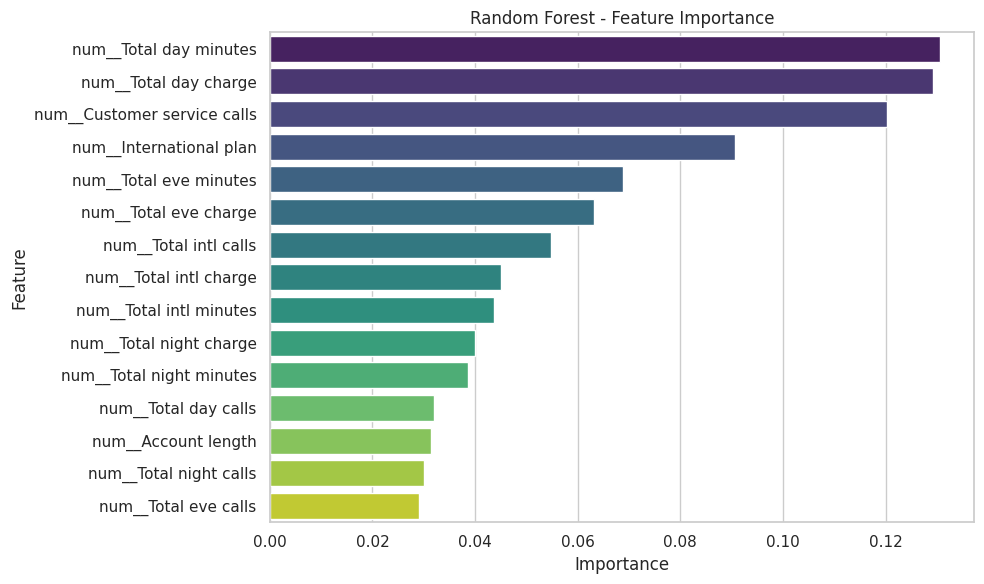

In [ ]:
# First, we get the best Random Forest model from Grid Search
best_rf_model = grid_rf.best_estimator_

# Then we take out the classifier part from the pipeline
rf_clf = best_rf_model.named_steps['classifier']

# We also take the preprocessing part (scaling and encoding steps)
preprocessor = best_rf_model.named_steps['preprocessing']

# Now we get the names of all the features after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Get the importance scores for each feature from the Random Forest
importances = rf_clf.feature_importances_

# Put everything into a DataFrame and sort from most to least important
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Let’s draw a barplot
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='viridis')
plt.title("Random Forest - Feature Importance")
plt.tight_layout()
plt.show()

According to this graph, our Random Forest model used the following 3 features the most when making predictions:

Total day minutes: The total talk time of the customer during the day. It makes sense if it is very high because daytime calls are generally more expensive and this can be directly related to the customer's bill. This can increase the risk of churn.

Total day charge: Charge information directly related to daily talk time. This is very natural because as the bill increases, the customer may decide to cancel.

Customer service calls: The number of times a customer calls customer service. This data indirectly signals dissatisfaction. The more calls there are, the higher the probability of a problem. This increases the probability of cancellation.

International plan: Does the customer have an international plan? This is also important because it can cause extra charges and these plans can be confusing or expensive for some customers.

The model found the customer's behavioral characteristics (such as daily talk time, call duration, bill amount) to be very meaningful for churn prediction.
At the same time, satisfaction indicators such as customer service calls are also very effective.
So, Random Forest was able to effectively evaluate not only technical numbers but also areas related to customer behavior and experience.

<ipython-input-72-631b6588e5bc>:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='coolwarm')


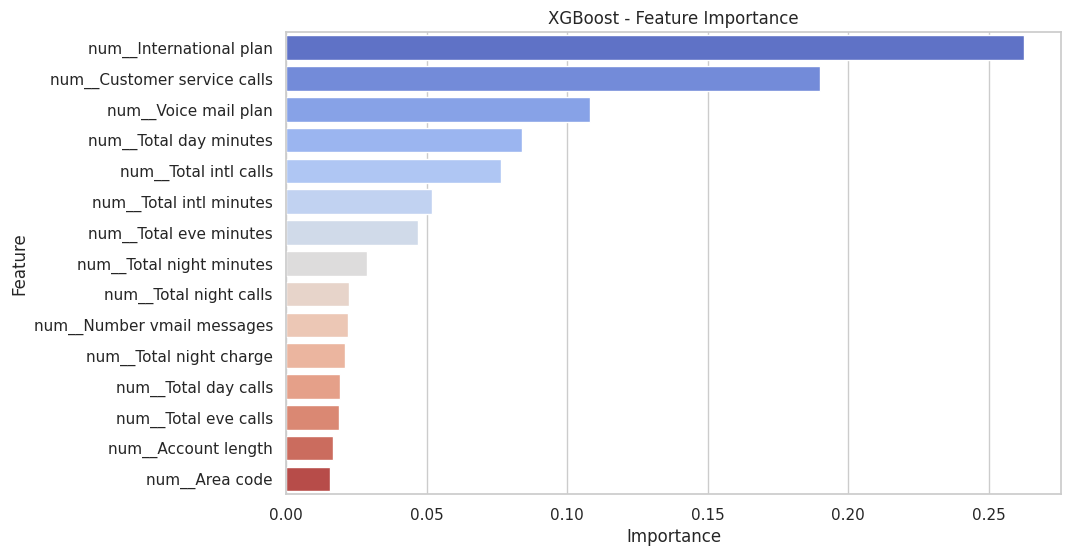

In [ ]:
# First, we get the best XGBoost model from our Grid Search results
best_xgb_model = grid_xgb.best_estimator_

# Then we get the XGBoost classifier part from the pipeline
xgb_clf = best_xgb_model.named_steps['classifier']

# Also get the preprocessing part
preprocessor = best_xgb_model.named_steps['preprocessing']

# Get the real feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Now get the feature importance values
importances = xgb_clf.feature_importances_

# Combine feature names and their importance values into a DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Let’s plot the top 15 most important features
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='coolwarm')
plt.title("XGBoost - Feature Importance")
plt.show()

The International plan model was the most impressive feature. This is very striking because this plan may bring extra charges for international calls.

If customers are on this plan, they usually pay more and this may affect the decision to cancel the subscription.

Customer service calls are again a very important signal.
This data indirectly reflects the problems and number of complaints experienced by the customer.
This is a behavior that establishes a strong relationship with churn.

Voice mail plan is also at the top.
Perhaps customers using this plan have a different service expectation and may be dissatisfied.
This was not so high in Random Forest. This difference is interesting.

Talk times such as total day minutes, intl calls, intl minutes are also important in XGBoost but not as high as Random Forest.

Why Did Random Forest and XGBoost Give Different Rankings?

The structure of the models are different from each other. Random Forest trains many decision trees independently and each works with different examples. As a result, it generally emphasizes “more general and balanced” signals.
XGBoost, on the contrary, trains trees sequentially, and each new tree tries to correct the mistakes of the previous one. That's why it is successful in learning more complex relationships.

The two models have different approaches to the types of features.In other words, while Random Forest emphasizes features that have a direct effect, such as total talk time, XGBoost can sometimes prefer categorical variables that make more indirect but strong distinctions.

For example, columns that take a value of 0 or 1 (binary), such as international plan, may be more valuable for XGBoost. Because this model gives more importance to variables that can gain a lot of information with a small number of divisions.

Random Forest, on the other hand, works more comfortably with numeric variables. For example, continuous values ​​such as talk time or bill amount may be more prominent for Random Forest because they offer more division options.

In addition, how these models measure what they call importance is different:
While XGBoost calculates how much information a feature provides to the model, Random Forest usually looks at the impurity reduction effect of the feature in decision trees.

Therefore, even if they work with the same data, the order of importance of the features does not turn out to be exactly the same. But still, strong signals like customer service calls are at the top of both models. This shows that the models exhibit some common behaviors.

As a result, each model looks at the data differently. While Random Forest tries to find more balanced and directly effective variables, XGBoost captures more detailed relationships. Therefore, interpreting the two together provides a more powerful analysis.

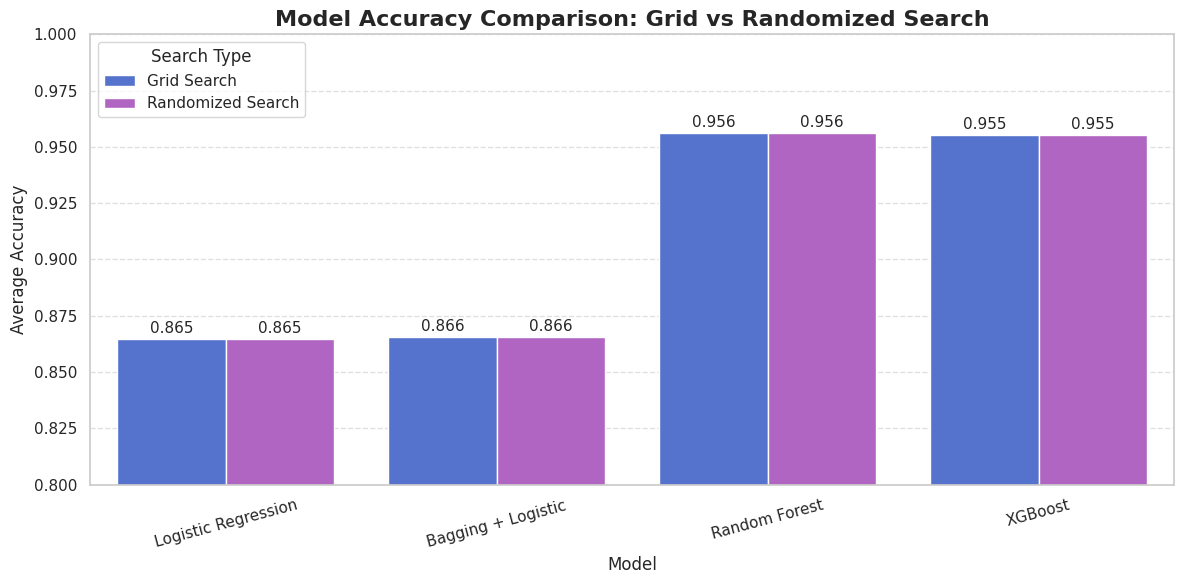

In [ ]:
# Accuracy results for each model using Grid Search and Randomized Search
# (we used best_score_ from each tuned model)
model_accuracy_results = [
    ("Logistic Regression", "Grid Search", grid_lr.best_score_),
    ("Logistic Regression", "Randomized Search", random_search.best_score_),

    ("Bagging + Logistic", "Grid Search", grid_bagging.best_score_),
    ("Bagging + Logistic", "Randomized Search", random_bagging.best_score_),

    ("Random Forest", "Grid Search", grid_rf.best_score_),
    ("Random Forest", "Randomized Search", random_rf.best_score_),

    ("XGBoost", "Grid Search", grid_xgb.best_score_),
    ("XGBoost", "Randomized Search", random_xgb.best_score_)
]

# Put results into a DataFrame so we can plot them easily
df_acc = pd.DataFrame(model_accuracy_results, columns=["Model", "Search Type", "Accuracy"])

# Set custom colors for bars
custom_palette = {
    "Grid Search": "#4169E1",
    "Randomized Search": "#BA55D3"
}

# Start drawing the bar chart
plt.figure(figsize=(12, 6))  # make it wide enough to read labels
ax = sns.barplot(data=df_acc, x="Model", y="Accuracy", hue="Search Type", palette=custom_palette)

# Add chart title and axis labels
plt.title("Model Accuracy Comparison: Grid vs Randomized Search", fontsize=16, fontweight='bold')
plt.ylabel("Average Accuracy", fontsize=12)
plt.xticks(rotation=15)
plt.ylim(0.80, 1.00)
plt.yticks(np.arange(0.80, 1.01, 0.025), fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.6)  # add gridlines for better reading

# Show accuracy values on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', label_type='edge', fontsize=11, padding=2)


plt.tight_layout()
plt.show()

In [ ]:
# -----------------------------------------------------------
# GridSearch ve RandomizedSearch best models

# GridSearch - Logistic Regression
lr_grid_proba = cross_val_predict(grid_lr.best_estimator_, X, y, cv=5, method='predict_proba')[:, 1]
print("Logistic Regression (GridSearch) ROC AUC:", roc_auc_score(y, lr_grid_proba))

# RandomSearch - Logistic Regression
lr_random_proba = cross_val_predict(random_search.best_estimator_, X, y, cv=5, method='predict_proba')[:, 1]
print("Logistic Regression (RandomSearch) ROC AUC:", roc_auc_score(y, lr_random_proba))

# GridSearch - Bagging
bagging_grid_proba = cross_val_predict(grid_bagging.best_estimator_, X, y, cv=5, method='predict_proba')[:, 1]
print("Bagging (GridSearch) ROC AUC:", roc_auc_score(y, bagging_grid_proba))

# RandomSearch - Bagging
bagging_random_proba = cross_val_predict(random_bagging.best_estimator_, X, y, cv=5, method='predict_proba')[:, 1]
print("Bagging (RandomSearch) ROC AUC:", roc_auc_score(y, bagging_random_proba))

# GridSearch - Random Forest
rf_grid_proba = cross_val_predict(grid_rf.best_estimator_, X, y, cv=5, method='predict_proba')[:, 1]
print("Random Forest (GridSearch) ROC AUC:", roc_auc_score(y, rf_grid_proba))

# RandomSearch - Random Forest
rf_random_proba = cross_val_predict(random_rf.best_estimator_, X, y, cv=5, method='predict_proba')[:, 1]
print("Random Forest (RandomSearch) ROC AUC:", roc_auc_score(y, rf_random_proba))

# GridSearch - XGBoost
xgb_grid_proba = cross_val_predict(grid_xgb.best_estimator_, X, y, cv=5, method='predict_proba')[:, 1]
print("XGBoost (GridSearch) ROC AUC:", roc_auc_score(y, xgb_grid_proba))

# RandomSearch - XGBoost
xgb_random_proba = cross_val_predict(random_xgb.best_estimator_, X, y, cv=5, method='predict_proba')[:, 1]
print("XGBoost (RandomSearch) ROC AUC:", roc_auc_score(y, xgb_random_proba))


Logistic Regression (GridSearch) ROC AUC: 0.8105896382248853
Logistic Regression (RandomSearch) ROC AUC: 0.8105885068291049
Bagging (GridSearch) ROC AUC: 0.8099051437777757
Bagging (RandomSearch) ROC AUC: 0.8099051437777757
Random Forest (GridSearch) ROC AUC: 0.9158784609396923
Random Forest (RandomSearch) ROC AUC: 0.9158784609396923
XGBoost (GridSearch) ROC AUC: 0.9161624412805591
XGBoost (RandomSearch) ROC AUC: 0.9161624412805591


This graph compares the accuracy results of different models after they were trained with the Grid Search and Randomized Search methods. There are two bars for each model; one is the Grid Search result and the other is the Randomized Search result.

The first thing that caught my attention was that both methods gave almost the same results in the Logistic Regression and Bagging + Logistic models. Both gave about 86% accuracy. This shows that these models are not very complex anyway and that parameter settings do not have a big effect on accuracy.

The accuracy rates are much higher in more powerful models such as Random Forest and XGBoost, around 95%. But interestingly, the Grid and Randomized Search results are almost exactly the same in these models. In other words, Randomized Search was able to give as good results as Grid Search. I think this is an important point because Randomized Search tries much fewer combinations and still achieves the same success.

In general, this graph showed me that not every model is affected by tuning in the same way. While parameter settings make a big difference in some models, they change almost nothing in others. Also, Randomized Search seems to save time and not lose much in performance. So, in a time-limited situation, it might make sense to choose Randomized Search.

<ipython-input-75-6281f404ff55>:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=df_roc_auc, x="Model", y="ROC AUC", palette="viridis")


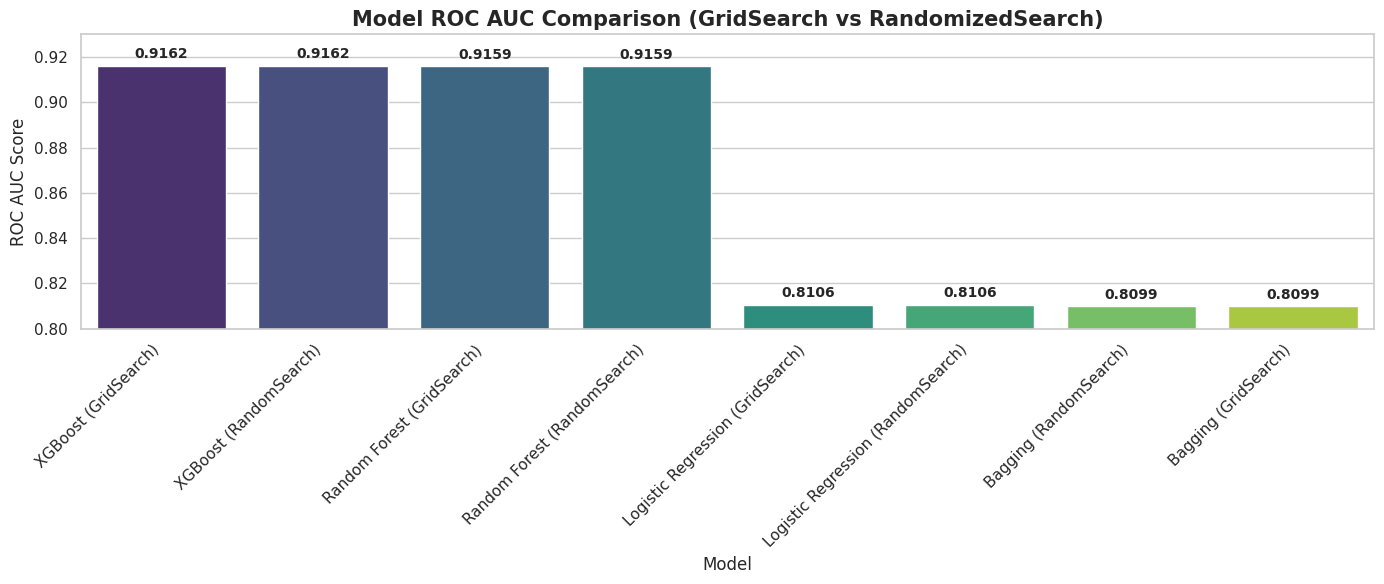

In [ ]:
# We use the best model found by GridSearch and RandomSearch
roc_auc_results = [
    ("Logistic Regression (GridSearch)", roc_auc_score(y, cross_val_predict(grid_lr.best_estimator_, X, y, cv=5, method='predict_proba')[:, 1])),
    ("Logistic Regression (RandomSearch)", roc_auc_score(y, cross_val_predict(random_search.best_estimator_, X, y, cv=5, method='predict_proba')[:, 1])),

    ("Bagging (GridSearch)", roc_auc_score(y, cross_val_predict(grid_bagging.best_estimator_, X, y, cv=5, method='predict_proba')[:, 1])),
    ("Bagging (RandomSearch)", roc_auc_score(y, cross_val_predict(random_bagging.best_estimator_, X, y, cv=5, method='predict_proba')[:, 1])),

    ("Random Forest (GridSearch)", roc_auc_score(y, cross_val_predict(grid_rf.best_estimator_, X, y, cv=5, method='predict_proba')[:, 1])),
    ("Random Forest (RandomSearch)", roc_auc_score(y, cross_val_predict(random_rf.best_estimator_, X, y, cv=5, method='predict_proba')[:, 1])),

    ("XGBoost (GridSearch)", roc_auc_score(y, cross_val_predict(grid_xgb.best_estimator_, X, y, cv=5, method='predict_proba')[:, 1])),
    ("XGBoost (RandomSearch)", roc_auc_score(y, cross_val_predict(random_xgb.best_estimator_, X, y, cv=5, method='predict_proba')[:, 1]))
]

#  Put results into a DataFrame and sort by ROC AUC score
df_roc_auc = pd.DataFrame(roc_auc_results, columns=["Model", "ROC AUC"])
df_roc_auc.sort_values("ROC AUC", ascending=False, inplace=True)

# Plot the ROC AUC scores using a bar chart
plt.figure(figsize=(14, 6))  # make the figure wide so labels fit
sns.set_style("whitegrid")   # clean background style

bars = sns.barplot(data=df_roc_auc, x="Model", y="ROC AUC", palette="viridis")

#  Add the score text above each bar
for bar in bars.patches:
    height = bar.get_height()
    bars.annotate(f'{height:.4f}',
                  (bar.get_x() + bar.get_width() / 2, height + 0.002),
                  ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title("Model ROC AUC Comparison (GridSearch vs RandomizedSearch)", fontsize=15, fontweight='bold')
plt.ylabel("ROC AUC Score")
plt.xticks(rotation=45, ha='right')
plt.ylim(0.80, 0.93)
plt.tight_layout()
plt.show()

In this graph, we compare the ROC AUC scores of the models. What we call ROC AUC is how well the models distinguish between classes. In other words, it measures not only their correct predictions, but also how well they can distinguish positives as truly positive and negatives as truly negative. The graph shows us the ROC AUC scores of models trained with both Grid Search and Randomized Search.

The first thing we noticed is that the ROC AUC scores of the XGBoost and Random Forest models are very high. Both are above 0.91 and there is almost no difference between them. This shows that these models not only make correct predictions, but also can very clearly distinguish users who will cancel their subscription from others. The Logistic Regression and Bagging models are weaker in this regard, because their ROC AUC scores are around 0.81. In other words, even if these models predict correctly, they are not very successful in distinguishing the positive class.

It is also noteworthy that the Grid and Randomized Search results are almost the same. This shows us that: Randomized Search works almost as well as Grid, despite having much fewer trials. Especially in strong models (XGBoost, Random Forest), this difference is almost negligible.

In conclusion, this graph shows that: If we have a problem where we want to separate the positive class well (for example, who will cancel the subscription), it is not enough to look at the accuracy rate alone. We also need to look at the ROC AUC score. And from this perspective, XGBoost and Random Forest are by far the most successful models.

<ipython-input-76-e00be908a6f6>:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(data=df_total_acc, x="Model", y="Accuracy", palette="cubehelix")  # colorful bars


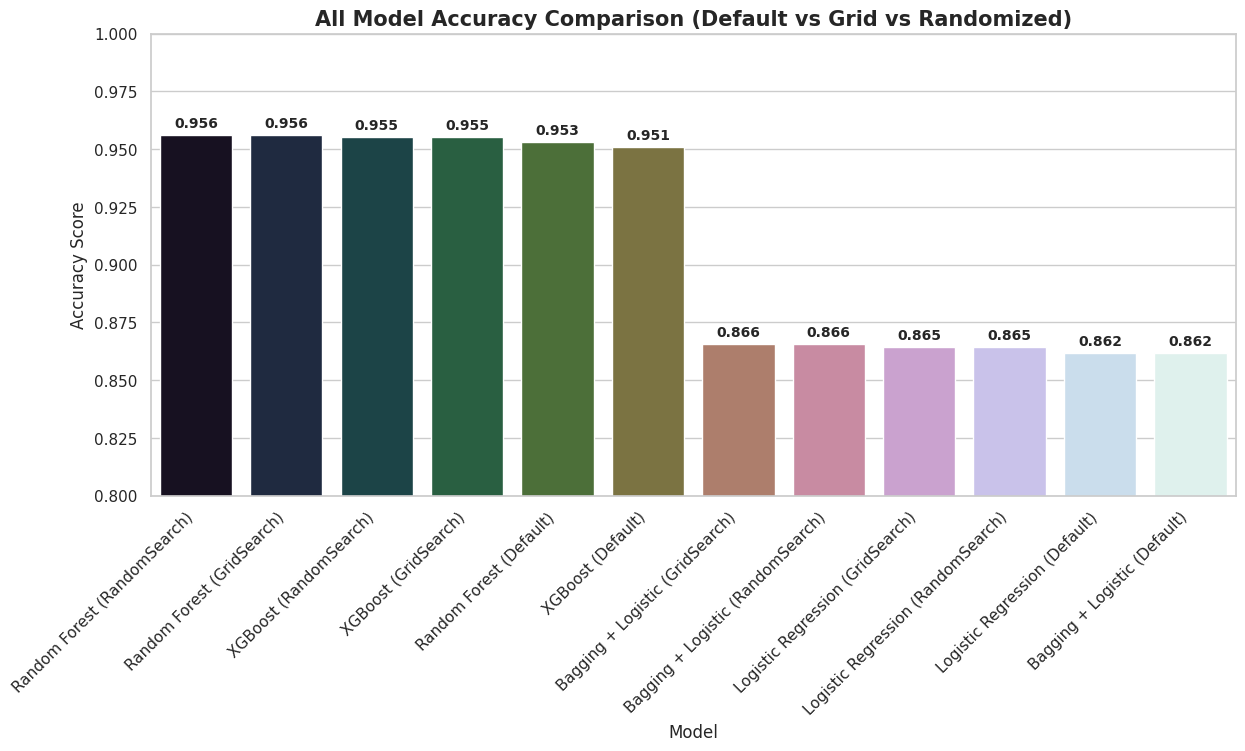

In [ ]:
# First, we store the average accuracy of each default model (no tuning yet)
default_accuracy = {
    "Logistic Regression": logistic_scores.mean(),
    "Bagging + Logistic": bagging_scores.mean(),
    "Random Forest": rf_scores.mean(),
    "XGBoost": xgb_scores.mean()
}

# Next, we store the best accuracy results from tuned models (GridSearch and RandomSearch)
tuned_accuracy = [
    ("Logistic Regression (GridSearch)", grid_lr.best_score_),
    ("Logistic Regression (RandomSearch)", random_search.best_score_),

    ("Bagging + Logistic (GridSearch)", grid_bagging.best_score_),
    ("Bagging + Logistic (RandomSearch)", random_bagging.best_score_),

    ("Random Forest (GridSearch)", grid_rf.best_score_),
    ("Random Forest (RandomSearch)", random_rf.best_score_),

    ("XGBoost (GridSearch)", grid_xgb.best_score_),
    ("XGBoost (RandomSearch)", random_xgb.best_score_)
]

# Now we also add the default model scores to the list
for model_name, acc in default_accuracy.items():
    tuned_accuracy.append((f"{model_name} (Default)", acc))

# Create a DataFrame with all model names and their accuracy scores
df_total_acc = pd.DataFrame(tuned_accuracy, columns=["Model", "Accuracy"])
df_total_acc.sort_values("Accuracy", ascending=False, inplace=True)  # sort from best to worst

# Plot the accuracy scores using bar chart
plt.figure(figsize=(14, 6))        # make it wide so all labels fit
sns.set_style("whitegrid")         # nice clean background
barplot = sns.barplot(data=df_total_acc, x="Model", y="Accuracy", palette="cubehelix")  # colorful bars

# Add the score numbers above each bar
for bar in barplot.patches:
    height = bar.get_height()
    barplot.annotate(f'{height:.3f}',                            # 3 decimals
                     (bar.get_x() + bar.get_width() / 2, height + 0.002),
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add title and axis settings
plt.title("All Model Accuracy Comparison (Default vs Grid vs Randomized)", fontsize=15, fontweight='bold')
plt.ylabel("Accuracy Score")
plt.xticks(rotation=45, ha='right')
plt.ylim(0.80, 1.00)
plt.show()

In this bar chart, we compared the accuracy of all our models: both the default versions and the tuned versions using Grid Search and Randomized Search.

The best results came from Random Forest, especially with Randomized Search and Grid Search. Both gave about 0.956 accuracy, which was the highest.

XGBoost also did very well. The tuned versions reached 0.955, and even the default version was close with 0.951.

Bagging + Logistic Regression had an accuracy of around 0.865–0.866, whether tuned or not. So tuning didn’t change much here.

Logistic Regression performed the lowest in terms of accuracy (~0.862), but it still gave stable results across all setups.

 In Conclusion Tuning helped more with complex models like Random Forest and XGBoost. For simpler models like Logistic Regression and Bagging, the improvement was small. This shows that parameter tuning is more effective for advanced models.